## 1 - imports e configuracao inicial

Nessa etapa as bibliotecas necessárias para manipulação e análise dos dados são importadas

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)



/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


## 2 - Carregamento e análise inicial do dataset

O dataset Iris é carregado diretamente do arquivo disponibilizado pelo Kaggle e depois, são realizadas verificações iniciais para compreender sua estrutura e dimensão.

In [51]:
df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

print("Primeiras linhas do dataset:")
display(df.head())

print("Dimensões do dataset:")
print(df.shape)

print("Colunas:")
print(df.columns)

print("Estatísticas descritivas:")
display(df.describe())

print("Valores nulos:")
print(df.isnull().sum())

Primeiras linhas do dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dimensões do dataset:
(150, 6)
Colunas:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Estatísticas descritivas:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Valores nulos:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## 2.1 - Análise exploratória adicional

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


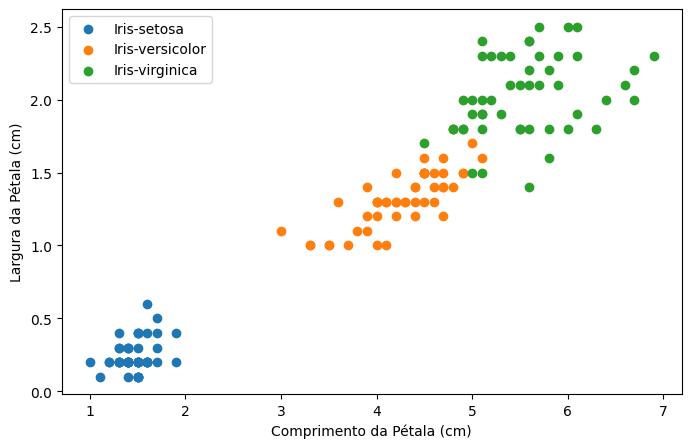

In [52]:
print(df['Species'].value_counts())

for especie in df['Species'].unique():
    subset = df[df['Species'] == especie]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=especie)

plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Largura da Pétala (cm)')
plt.legend()
plt.show()

## 3 - Separação das features e do alvo

As variáveis utilizadas como entrada do modelo são separadas da variável que representa a classe a ser prevista. As quatro medidas das flores são utilizadas como features, enquanto a espécie (`Species`) é definida como variável alvo. A coluna `Id` não é utilizada

In [53]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


## 4 - Separação entre treino e teste

Os dados são divididos em dois conjuntos. O conjunto de treinamento será utilizado para que o SVM aprenda os padrões presentes nos dados, enquanto o conjunto de teste será mantido separado para avaliar sua capacidade de classificação em dados que não participaram do treinamento.

In [54]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (120, 4)
Formato de X_test: (30, 4)
Formato de y_train: (120,)
Formato de y_test: (30,)


## 5. Padronização das features

As variáveis de entrada são padronizadas utilizando o `StandardScaler`. Essa etapa coloca as features em uma escala comparável, evitando que diferenças de escala influenciem o treinamento do SVM

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Primeiras linhas de X_train padronizado:")
print(X_train_scaled[:5])

Primeiras linhas de X_train padronizado:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


## 6 - Treinamento e previsão com SVM

Nesta etapa é criado o classificador SVM utilizando o kernel RBF. O modelo é treinado com os dados de treinamento padronizados e posteriormente utilizado para classificar as amostras do conjunto de teste.

In [56]:
modelo_svm = SVC(kernel="rbf")

modelo_svm.fit(X_train_scaled, y_train)

y_pred = modelo_svm.predict(X_test_scaled)

print("Previsões:")
print(y_pred)

Previsões:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


## 7 - Avaliação do modelo

O desempenho do SVM é avaliado comparando as classes reais do conjunto de teste com as previsões realizadas pelo modelo. São utilizadas a acurácia e o relatório de classificação, que apresenta precision, recall e F1-score para cada classe.

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Acurácia: 96.67%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## 8. Matriz de confusão

A matriz de confusão permite visualizar os acertos e erros do classificador para cada espécie. Os valores da diagonal principal representam as classificações corretas, enquanto os valores fora da diagonal representam classificações incorretas.

Matriz de Confusão:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


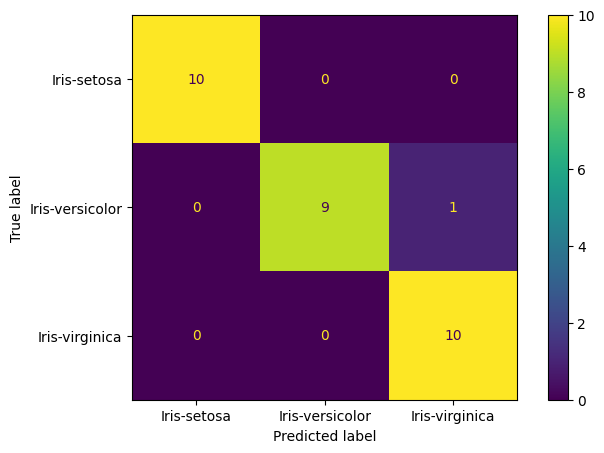

In [58]:
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_svm.classes_
)

disp.plot()
plt.show()


## Conclusão

O modelo de classificação SVM foi treinado utilizando as quatro características das flores do dataset Iris: comprimento e largura da sépala e comprimento e largura da pétala. Os dados foram divididos em conjuntos de treinamento e teste e as features foram padronizadas antes do treinamento.

Na avaliação, o modelo apresentou **96,67% de acurácia**, classificando corretamente 29 das 30 amostras do conjunto de teste. O `classification_report` apresentou bons resultados para as três classes, com destaque para a classificação da `Iris-setosa`, que apresentou precision, recall e F1-score iguais a 1,00.

A matriz de confusão mostrou que o único erro ocorreu na classe `Iris-versicolor`, que foi classificada como `Iris-virginica`. Dessa forma, os resultados obtidos mostram o desempenho do SVM na classificação das amostras utilizadas no conjunto de teste.